In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# ============================================================
# 1. LOAD FEATURE DATA
# ============================================================

df = pd.read_csv(
    "../../data/processed/paysim_features.csv"
)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully.
Shape: (6362620, 24)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'log_amount', 'hour', 'day', 'origin_balance_utilization', 'origin_balance_zero', 'destination_balance_zero', 'full_origin_balance_transfer', 'destination_previous_transactions', 'origin_previous_transactions', 'origin_balance_depleted', 'destination_balance_change', 'origin_balance_change', 'amount_to_destination_balance', 'zero_amount_transaction']

First 5 rows:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        2

In [3]:
# ============================================================
# 2. DATASET STRUCTURE
# ============================================================

print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMemory Usage:")
print(f"{df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

Shape: (6362620, 24)

Data Types:
step                                   int64
type                                     str
amount                               float64
nameOrig                                 str
oldbalanceOrg                        float64
newbalanceOrig                       float64
nameDest                                 str
oldbalanceDest                       float64
newbalanceDest                       float64
isFraud                                int64
log_amount                           float64
hour                                   int64
day                                    int64
origin_balance_utilization           float64
origin_balance_zero                    int64
destination_balance_zero               int64
full_origin_balance_transfer           int64
destination_previous_transactions      int64
origin_previous_transactions           int64
origin_balance_depleted                int64
destination_balance_change           float64
origin_balance_change

In [4]:
# ============================================================
# 3. TARGET DISTRIBUTION
# ============================================================

fraud_counts = df["isFraud"].value_counts()

print("Transaction Class Distribution:")
print(fraud_counts)

print("\nPercentage Distribution:")
print(
    (df["isFraud"].value_counts(normalize=True) * 100)
    .round(4)
)

print("\nFraud-to-Legitimate Ratio:")
print(
    f"{fraud_counts[0] / fraud_counts[1]:,.2f} : 1"
)

Transaction Class Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Percentage Distribution:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64

Fraud-to-Legitimate Ratio:
773.70 : 1


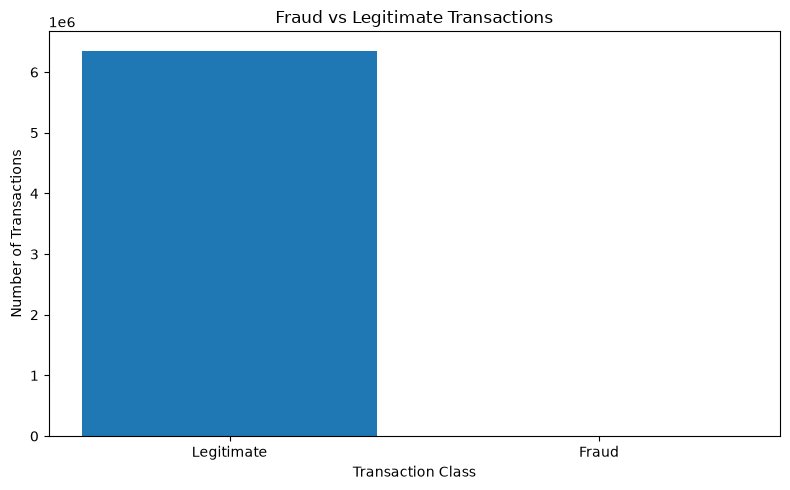

In [7]:
# ============================================================
# 4. FRAUD VS LEGITIMATE TRANSACTIONS
# ============================================================

class_counts = df["isFraud"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    ["Legitimate","Fraud"],
    [class_counts[0],class_counts[1]]
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

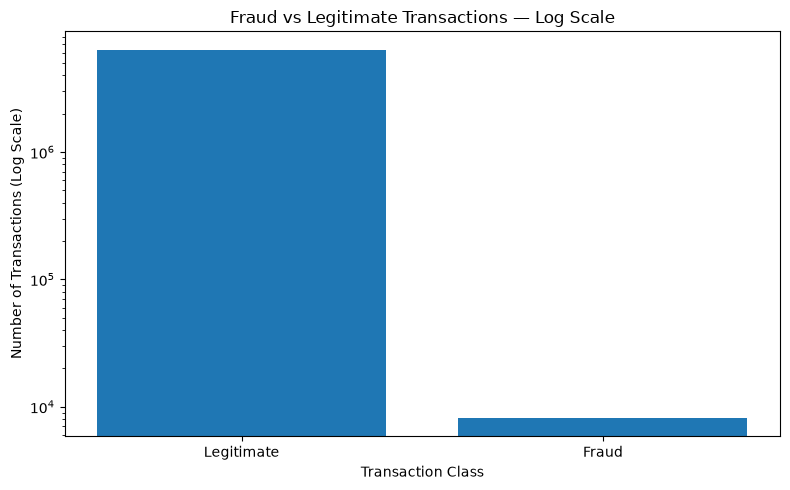

In [8]:
# ============================================================
# 5. FRAUD VS LEGITIMATE TRANSACTIONS — LOG SCALE
# ============================================================

class_counts = df["isFraud"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    ["Legitimate", "Fraud"],
    [class_counts[0], class_counts[1]]
)

plt.yscale("log")

plt.title("Fraud vs Legitimate Transactions — Log Scale")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions (Log Scale)")

plt.tight_layout()
plt.show()

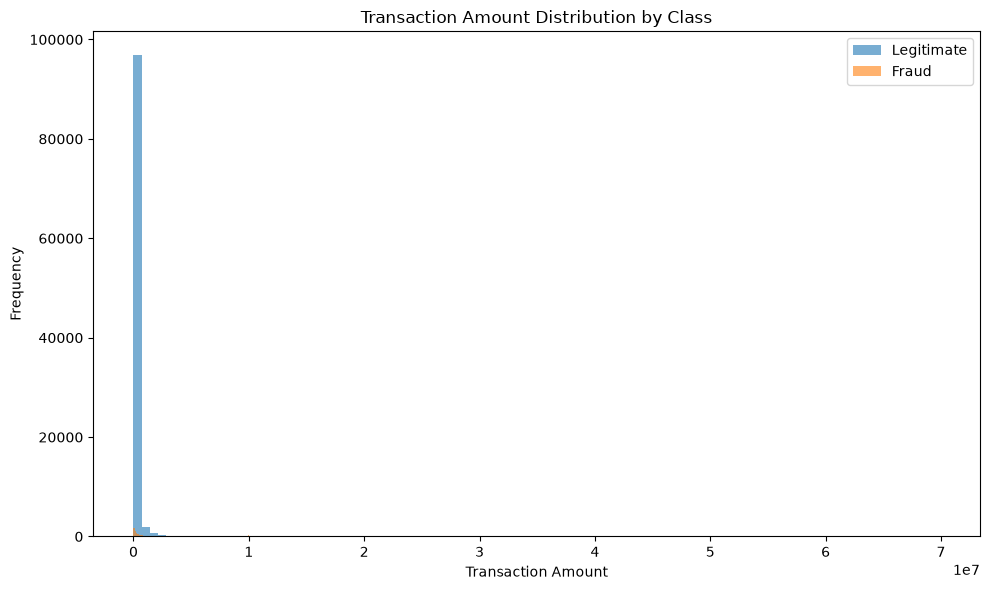

In [13]:
# ============================================================
# 6. TRANSACTION AMOUNT DISTRIBUTION BY CLASS
# ============================================================

fraud_df = df[df["isFraud"] == 1]

legitimate_sample = df[df["isFraud"] == 0].sample(
    n=100000,
    random_state=42
)

plt.figure(figsize=(10, 6))

plt.hist(
    legitimate_sample["amount"],
    bins=100,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    fraud_df["amount"],
    bins=100,
    alpha=0.6,
    label="Fraud"
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

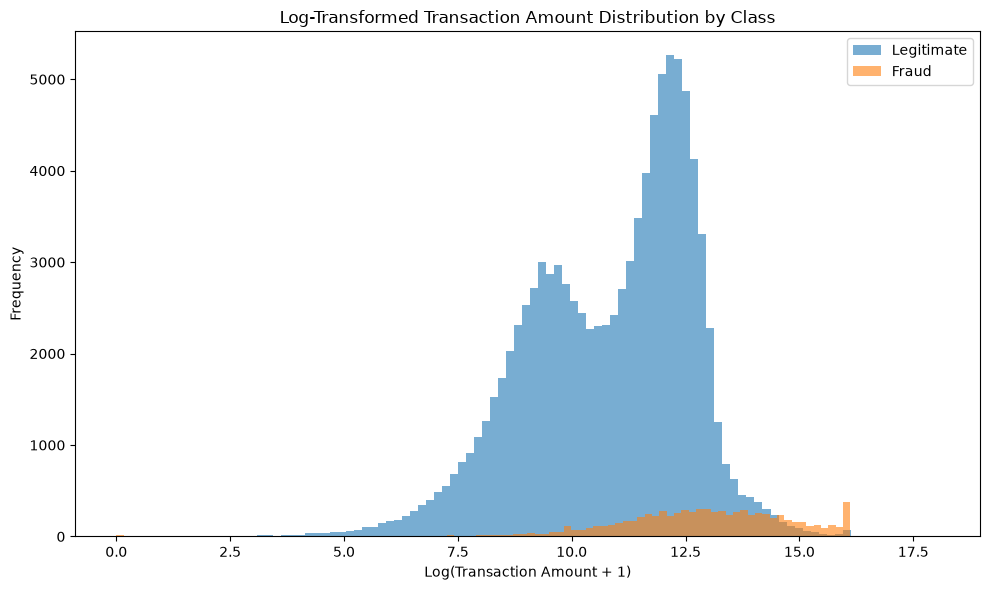

In [14]:
# ============================================================
# 7. LOG-TRANSFORMED AMOUNT DISTRIBUTION BY CLASS
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    legitimate_sample["log_amount"],
    bins=100,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    fraud_df["log_amount"],
    bins=100,
    alpha=0.6,
    label="Fraud"
)

plt.title("Log-Transformed Transaction Amount Distribution by Class")
plt.xlabel("Log(Transaction Amount + 1)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 8. TRANSACTION AMOUNT STATISTICS BY CLASS
# ============================================================

amount_stats = (
    df.groupby("isFraud")["amount"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q95=lambda x: x.quantile(0.95),
        q99=lambda x: x.quantile(0.99),
        max="max"
    )
    .round(2)
)

amount_stats.index = ["Legitimate", "Fraud"]

amount_stats

,count,mean,median,std,min,q25,q75,q95,q99,max
Legitimate,6354407,178197.04,74684.72,596236.98,0.01,13368.40,208364.76,515610.42,1586064.17,92445516.64
Fraud,8213,1467967.30,441423.44,2404252.95,0.00,127091.33,1517771.48,8006429.04,10000000.00,10000000.00


In [17]:
# ============================================================
# 9. FRAUD RATE BY TRANSACTION TYPE
# ============================================================

type_analysis = (
    df.groupby("type")
    .agg(
        total_transactions=("isFraud","count"),
        fraud_transactions=("isFraud","sum")
    )
)

type_analysis["Fraud_rate_percent"] = (
    type_analysis["fraud_transactions"]
    / type_analysis["total_transactions"]
    * 100.0
)

type_analysis = type_analysis.sort_values("Fraud_rate_percent",ascending=False)

type_analysis.round(4)

,total_transactions,fraud_transactions,Fraud_rate_percent
type,,,
TRANSFER,532909,4097,0.7688
CASH_OUT,2237500,4116,0.1840
CASH_IN,1399284,0,0.0000
DEBIT,41432,0,0.0000
PAYMENT,2151495,0,0.0000


In [18]:
# ============================================================
# 10. ORIGIN BALANCE UTILIZATION BY CLASS
# ============================================================

utilization_stats = (
    df.groupby("isFraud")["origin_balance_utilization"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q95=lambda x: x.quantile(0.95),
        max="max"
    )
    .round(4)
)

utilization_stats.index = ["Legitimate", "Fraud"]

utilization_stats

,count,mean,median,q25,q75,q95,max
Legitimate,4251999,122.2727,0.7347,0.0743,6.6847,177.2671,3.925476e+06
Fraud,8172,0.9988,1.0000,1.0000,1.0000,1.0000,2.952660e+01


In [20]:
# ============================================================
# 11. ORIGIN BALANCE UTILIZATION MISSINGNESS BY CLASS
# ============================================================

missing_utilization = (
    df.groupby("isFraud")["origin_balance_utilization"]
    .agg(
        total_transactions="size",
        missing_values=lambda x: x.isna().sum()
    )
)

missing_utilization["missing_percent"] = (
    missing_utilization["missing_values"]
    / missing_utilization["total_transactions"]
    * 100
)

missing_utilization.index = ["Legitimate", "Fraud"]

missing_utilization.round(4)

,total_transactions,missing_values,missing_percent
Legitimate,6354407,2102408,33.0858
Fraud,8213,41,0.4992


In [21]:
# ============================================================
# 12. BEHAVIORAL FEATURE DISTRIBUTION BY CLASS
# ============================================================

behavioral_features = [
    "destination_previous_transactions",
    "origin_previous_transactions"
]

behavior_stats = (
    df.groupby("isFraud")[behavioral_features]
    .agg(["mean", "median", "max"])
)

behavior_stats

destination_previous_transactions              \
                                     mean median  max   
isFraud                                                 
0                                5.099214    2.0  112   
1                                2.701327    0.0   61   

        origin_previous_transactions             
                                mean median max  
isFraud                                          
0                           0.001465    0.0   2  
1                           0.002192    0.0   1

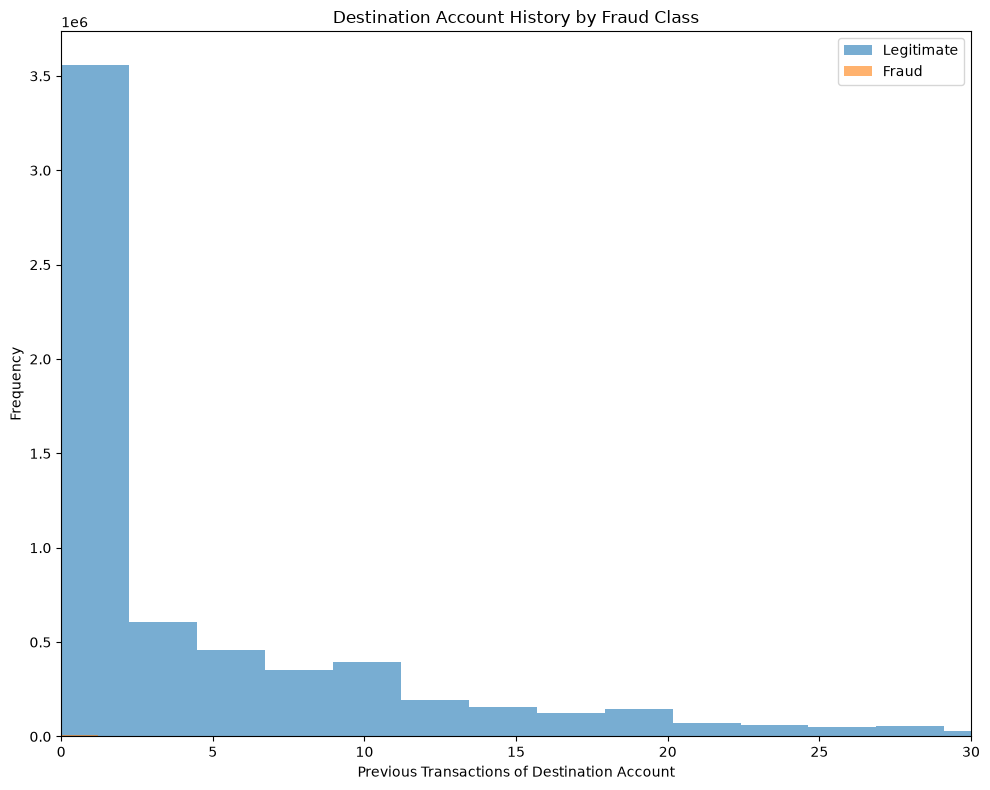

In [22]:
plt.figure(figsize=(10,8))

plt.hist(
    df[df["isFraud"] == 0]["destination_previous_transactions"],
    bins=50,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    df[df["isFraud"] == 1]["destination_previous_transactions"],
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.xlim(0, 30)

plt.title("Destination Account History by Fraud Class")
plt.xlabel("Previous Transactions of Destination Account")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()



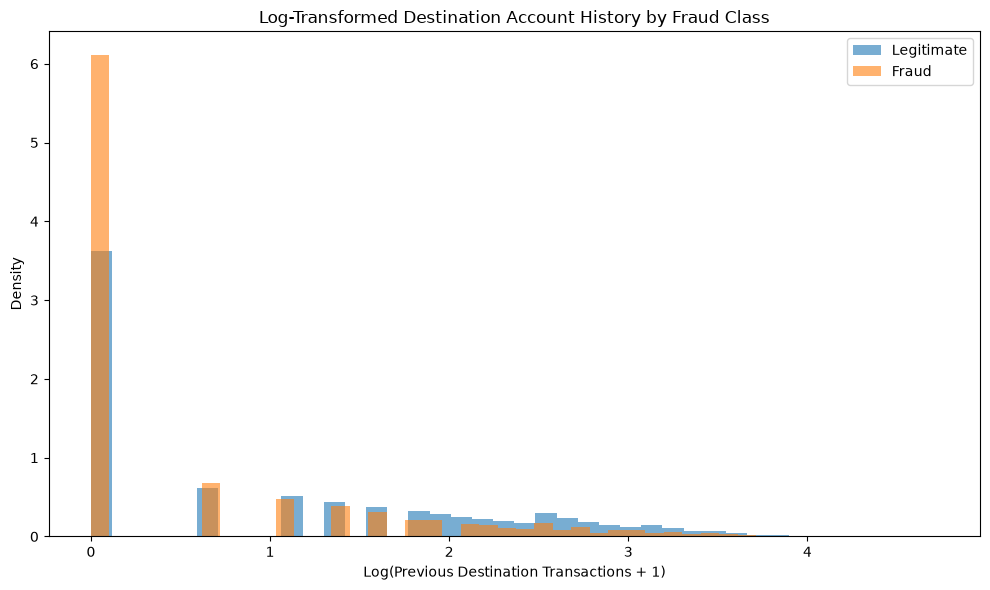

In [23]:
# ============================================================
# 14. LOG-TRANSFORMED DESTINATION ACCOUNT HISTORY
# ============================================================

df["log_destination_history"] = np.log1p(
    df["destination_previous_transactions"]
)

plt.figure(figsize=(10, 6))

plt.hist(
    df[df["isFraud"] == 0]["log_destination_history"],
    bins=40,
    density=True,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    df[df["isFraud"] == 1]["log_destination_history"],
    bins=40,
    density=True,
    alpha=0.6,
    label="Fraud"
)

plt.title("Log-Transformed Destination Account History by Fraud Class")
plt.xlabel("Log(Previous Destination Transactions + 1)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 15. ORIGIN BALANCE DEPLETION BY FRAUD CLASS
# ============================================================

depletion_stats = (
    df.groupby("isFraud")["origin_balance_depleted"]
    .agg(
        total_transactions="size",
        depleted_transactions="sum"
    )
)

depletion_stats["depletion_rate_percent"] = (
    depletion_stats["depleted_transactions"]
    / depletion_stats["total_transactions"]
    * 100
)

depletion_stats.index = ["Legitimate", "Fraud"]

depletion_stats.round(4)

,total_transactions,depleted_transactions,depletion_rate_percent
Legitimate,6354407,1512569,23.8035
Fraud,8213,8012,97.5527


In [25]:
# ============================================================
# 16. NUMERICAL FEATURE CORRELATION WITH FRAUD
# ============================================================

numeric_features = [
    "amount",
    "log_amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "origin_balance_utilization",
    "origin_balance_zero",
    "destination_balance_zero",
    "full_origin_balance_transfer",
    "destination_previous_transactions",
    "origin_balance_depleted",
    "destination_balance_change",
    "origin_balance_change",
    "amount_to_destination_balance",
    "zero_amount_transaction"
]

correlation_with_fraud = (
    df[numeric_features + ["isFraud"]]
    .corr(numeric_only=True)["isFraud"]
    .drop("isFraud")
    .sort_values(key=abs, ascending=False)
)

correlation_with_fraud

full_origin_balance_transfer         0.988042
origin_balance_change                0.362472
amount                               0.076688
origin_balance_depleted              0.062091
zero_amount_transaction              0.044109
log_amount                           0.040640
destination_balance_change           0.027028
origin_balance_zero                 -0.024874
destination_balance_zero             0.016471
destination_previous_transactions   -0.010972
oldbalanceOrg                        0.010154
newbalanceOrig                      -0.008148
oldbalanceDest                      -0.005885
origin_balance_utilization          -0.001279
newbalanceDest                       0.000535
amount_to_destination_balance        0.000430
Name: isFraud, dtype: float64

In [26]:
# ============================================================
# 17. FEATURE-TO-FEATURE CORRELATION
# ============================================================

feature_corr = (
    df[numeric_features]
    .corr()
)

high_corr_pairs = (
    feature_corr
    .where(
        np.triu(
            np.ones(feature_corr.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs["correlation"].abs() >= 0.70
    ]
    .sort_values(
        "correlation",
        key=abs,
        ascending=False
    )
)

high_corr_pairs

,feature_1,feature_2,correlation
35,oldbalanceOrg,newbalanceOrig,0.998803
69,oldbalanceDest,newbalanceDest,0.976569
12,amount,destination_balance_change,0.845964
